In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_ollama import ChatOllama
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
llm = ChatOllama(model='llama3.2')

In [3]:
class JokeState(TypedDict):
    
    topic: str
    joke: str
    explanation: str

In [4]:
def generate_joke(state: JokeState): 
    
    prompt = f'Generate a joke on topic {state["topic"]}'
    res = llm.invoke(prompt).content
    
    return {'joke': res}

def generate_exp(state: JokeState):
    
    prompt = f'Generate a explanation for the joke {state["joke"]}'
    res = llm.invoke(prompt).content
    
    return {'explanation': res}

In [5]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_exp', generate_exp)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_exp')
graph.add_edge('generate_exp', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

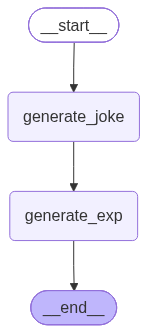

In [6]:
workflow

In [9]:
config1 = {'configurable': {'thread_id': 1}}
workflow.invoke({'topic': 'WWE'}, config=config1)

{'topic': 'WWE',
 'joke': 'Why did John Cena bring a ladder to the ring?\n\nBecause he wanted to take his career to the next level! (get it?)',
 'explanation': 'A classic joke!\n\nThe joke "Why did John Cena bring a ladder to the ring?" is a play on words, and the punchline "Because he wanted to take his career to the next level!" is a clever pun.\n\nThe setup of the joke is trying to trick the listener into thinking that John Cena, a professional wrestler, would bring a ladder to the ring for a literal reason, perhaps to climb over opponents or use as a prop. However, the punchline subverts this expectation by giving a completely different meaning to the phrase "take it to the next level."\n\nIn a professional wrestling context, "taking it to the next level" is a common idiomatic expression that means to elevate one\'s performance, skill, or experience to a higher level. In this case, the joke is using this phrase to make a wordplay with the physical meaning of "next level," which is 

In [10]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'WWE', 'joke': 'Why did John Cena bring a ladder to the ring?\n\nBecause he wanted to take his career to the next level! (get it?)', 'explanation': 'A classic joke!\n\nThe joke "Why did John Cena bring a ladder to the ring?" is a play on words, and the punchline "Because he wanted to take his career to the next level!" is a clever pun.\n\nThe setup of the joke is trying to trick the listener into thinking that John Cena, a professional wrestler, would bring a ladder to the ring for a literal reason, perhaps to climb over opponents or use as a prop. However, the punchline subverts this expectation by giving a completely different meaning to the phrase "take it to the next level."\n\nIn a professional wrestling context, "taking it to the next level" is a common idiomatic expression that means to elevate one\'s performance, skill, or experience to a higher level. In this case, the joke is using this phrase to make a wordplay with the physical meaning of "ne

## Time Travel

In [12]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1a3e0c-c05a-689a-8007-cf8830d5c188"}})

StateSnapshot(values={'topic': 'Virat Kohli', 'joke': 'Why did Virat Kohli bring a ladder to the pitch?\n\nBecause he wanted to take his game to the next level! (get it?)', 'explanation': 'A classic cricket-themed joke!\n\nThe joke relies on a play on words, where "taking his game to the next level" is a common idiomatic expression that means to improve or elevate one\'s performance or skills. However, in the context of cricket, "the next level" also literally refers to the boundary line of the pitch, which is the area in which the game is played.\n\nBy bringing a ladder to the pitch, Virat Kohli is essentially creating a temporary structure to reach the boundary line, allowing him to "take his game to the next level" in a clever and humorous way. The punchline is a clever wordplay that connects the idiomatic expression with the literal meaning of "the next level" in the context of the game.'}, next=('__start__',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1a3e0c-c

In [13]:
workflow.invoke(None, {'configurable': {'thread_id': 1, 'checkpoint_id': '1f1a3e0c-c05a-689a-8007-cf8830d5c188'}})

{'topic': 'WWE',
 'joke': 'Why did John Cena bring a ladder to the ring?\n\nBecause he wanted to take his career to a whole new level!',
 'explanation': 'That\'s a classic joke, but it\'s actually a play on John Cena\'s finishing move in WWE, known as the "Attitude Adjustment," which involves him lifting his opponent up and slamming them into the mat. The joke is a clever pun on the phrase "take it to the next level," which has a double meaning of both elevating one\'s career and executing a high-flying move in a literal sense.\n\nIn this joke, the ladder is used as a prop to create a clever connection between the setup and the punchline, setting the stage for the expected wordplay. The use of a ladder also adds an element of visual humor, as it\'s an unexpected object for John Cena to bring into the ring.\n\nOverall, the joke relies on a combination of wordplay, clever setup, and a nod to John Cena\'s WWE persona to create a funny and memorable punchline.'}

## Updating State

In [14]:

workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f06cc6e-7232-6cb1-8000-f71609e6cec5", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1a3e44-245d-623e-8000-8c2875ebda57'}}

In [15]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a3e44-245d-623e-8000-8c2875ebda57'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-08-29T20:00:18.493900+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f06cc6e-7232-6cb1-8000-f71609e6cec5'}}, tasks=(PregelTask(id='8aca2722-e12c-9a9d-64b4-aee373ec16b7', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'WWE', 'joke': 'Why did John Cena bring a ladder to the ring?\n\nBecause he wanted to take his career to a whole new level!', 'explanation': 'That\'s a classic joke, but it\'s actually a play on John Cena\'s finishing move in WWE, known as the "Attitude Adjustment," which involves him lifting his opponent up and slamming them into the mat. The jo